# 🎬 Análisis de Ventas de Películas
**Herramientas:** Python · Pandas · Matplotlib · Statsmodels  
**Objetivo:** Combinar datos de ventas y promociones, identificar patrones y entrenar un modelo de regresión lineal para predecir las ventas semanales de boletos.


## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os

## 2. Cargar los datos

Cargamos los dos CSV en DataFrames independientes.

In [2]:
df_ventas    = pd.read_csv("workspace/ventas_peliculas.csv", parse_dates=["fecha"])
df_promocion = pd.read_csv("workspace/promocion_peliculas.csv", parse_dates=["fecha"])

## 3. Combinación de DataFrames

Combinamos ambos DataFrames con un left join sobre `fecha` y `titulo`. Usamos `validate="1:m"` porque una misma fecha y título puede tener múltiples registros promocionales. Rellenamos los nulos resultantes con `ffill()` y `bfill()`.

In [3]:
df = pd.merge(df_ventas, df_promocion, on=["fecha", "titulo"], how="left", validate="1:m")

# Nulos antes del relleno
print("Nulos antes del relleno:")
print(df.isna().sum())

# Rellenamos con 0 las columnas promocionales cuando no hay registro (sin evento = 0)
df["eventos_promocionales"]  = df["eventos_promocionales"].fillna(0)
df["participacion_promocion"] = df["participacion_promocion"].fillna(0)

# Para el resto de columnas, ffill y bfill
df = df.ffill().bfill()

# Nulos después del relleno
print("\nNulos después del relleno:")
print(df.isna().sum())

Nulos antes del relleno:
fecha                      0
titulo                     0
ventas_boletos             0
calificacion               0
eventos_promocionales      0
participacion_promocion    0
dtype: int64

Nulos después del relleno:
fecha                      0
titulo                     0
ventas_boletos             0
calificacion               0
eventos_promocionales      0
participacion_promocion    0
dtype: int64


## 4. Identificación de valores nulos

Verificamos cuántos valores nulos quedan tras la combinación.

In [4]:
print(df.isna().sum())

fecha                      0
titulo                     0
ventas_boletos             0
calificacion               0
eventos_promocionales      0
participacion_promocion    0
dtype: int64


## 5. Visualización de ventas

### 5.1 Ventas semanales de boletos

Representamos la evolución de las ventas de boletos a lo largo del tiempo con un gráfico de líneas.

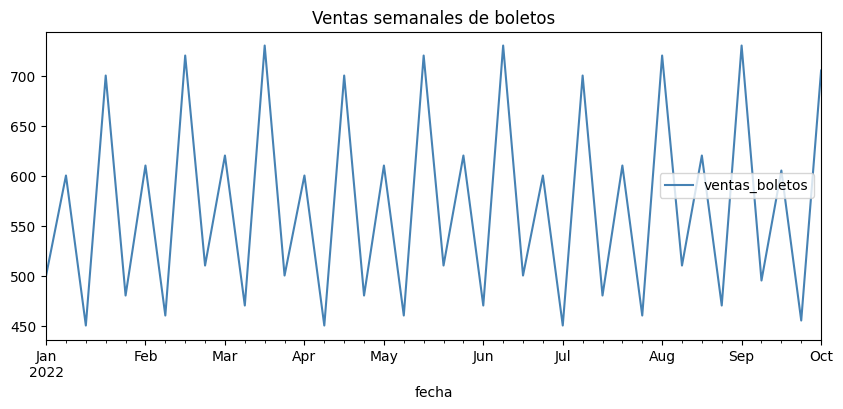

In [5]:
df.plot(x="fecha", y="ventas_boletos", kind="line", figsize=(10, 4),
        title="Ventas semanales de boletos", color="steelblue")
plt.show()

### 5.2 Ventas promedio: semanas con y sin eventos promocionales

Comparamos las ventas promedio según si hubo o no eventos promocionales.

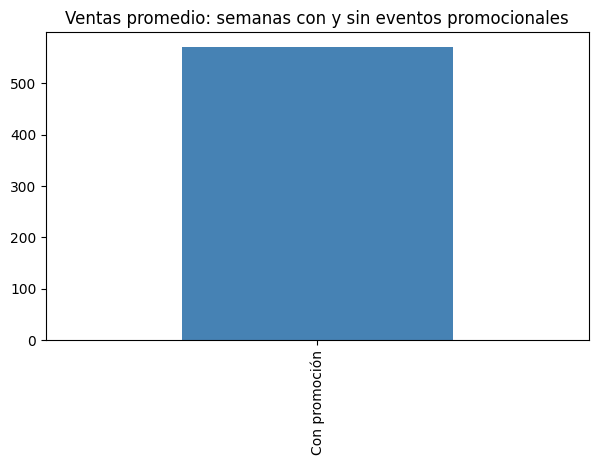

In [6]:
# Indicador binario: 0 = sin evento, 1 = con evento
df["con_evento"] = (df["eventos_promocionales"] > 0).astype(int)

ventas_por_evento = df.groupby("con_evento")["ventas_boletos"].mean()
ventas_por_evento.index = ventas_por_evento.index.map({0: "Sin promoción", 1: "Con promoción"})
ventas_por_evento.index.name = None

ventas_por_evento.plot(kind="bar", figsize=(7, 4), color="steelblue",
                       title="Ventas promedio: semanas con y sin eventos promocionales")
plt.show()

## 6. Detección de outliers

Usamos un box plot sobre `ventas_boletos` para identificar visualmente los valores extremos.

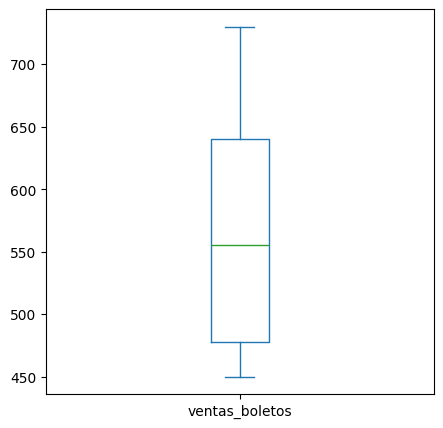

Outliers detectados: 0
Empty DataFrame
Columns: [fecha, titulo, ventas_boletos]
Index: []


In [7]:
df["ventas_boletos"].plot.box(figsize=(5, 5))
plt.show()

# Identificación programática de outliers mediante IQR
Q1  = df["ventas_boletos"].quantile(0.25)
Q3  = df["ventas_boletos"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["ventas_boletos"] < Q1 - 1.5 * IQR) | (df["ventas_boletos"] > Q3 + 1.5 * IQR)]
print(f"Outliers detectados: {len(outliers)}")
print(outliers[["fecha", "titulo", "ventas_boletos"]])

## 7. Análisis de correlación

Calculamos la correlación de Pearson entre `ventas_boletos`, `calificacion`, `eventos_promocionales` y `participacion_promocion`.

                         ventas_boletos  calificacion  eventos_promocionales  \
ventas_boletos                 1.000000      0.891084              -0.024186   
calificacion                   0.891084      1.000000              -0.112398   
eventos_promocionales         -0.024186     -0.112398               1.000000   
participacion_promocion       -0.222780     -0.254830               0.829671   

                         participacion_promocion  
ventas_boletos                         -0.222780  
calificacion                           -0.254830  
eventos_promocionales                   0.829671  
participacion_promocion                 1.000000  


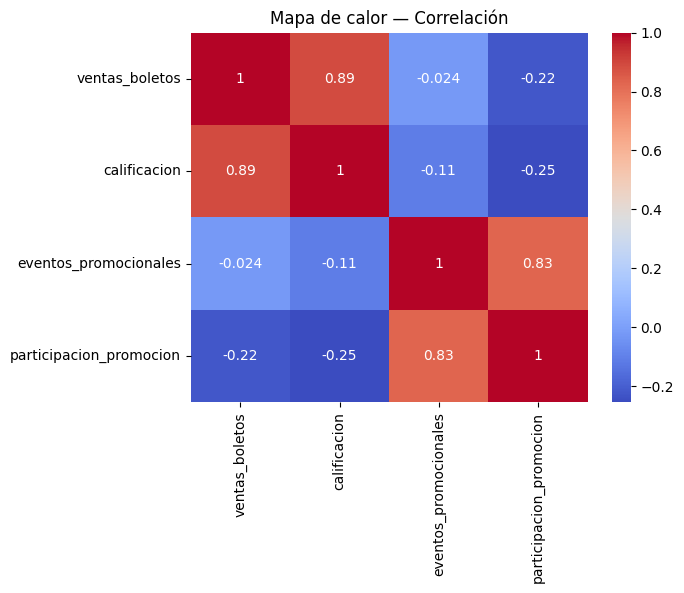

In [8]:
correlacion = df[["ventas_boletos", "calificacion", "eventos_promocionales", "participacion_promocion"]].corr()
print(correlacion)

# Mapa de calor para visualizar la correlación
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.title("Mapa de calor — Correlación")
plt.show()

## 8. Modelo de regresión lineal

Entrenamos un modelo OLS (Mínimos Cuadrados Ordinarios) con `statsmodels` para predecir `ventas_boletos` a partir de `calificacion`, `eventos_promocionales` y `participacion_promocion`.

In [9]:
# Variables independientes (X) y dependiente (y)
X = df[["calificacion", "eventos_promocionales", "participacion_promocion"]]
y = df["ventas_boletos"]

# Split temporal: 80% entrenamiento, 20% prueba
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Añadimos la constante para el término independiente
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

# Entrenamos el modelo OLS
modelo = sm.OLS(y_train, X_train).fit()

## 9. Evaluación del modelo

Comparamos gráficamente los valores reales frente a los predichos y mostramos el resumen completo del modelo con coeficientes, p-valores y R².

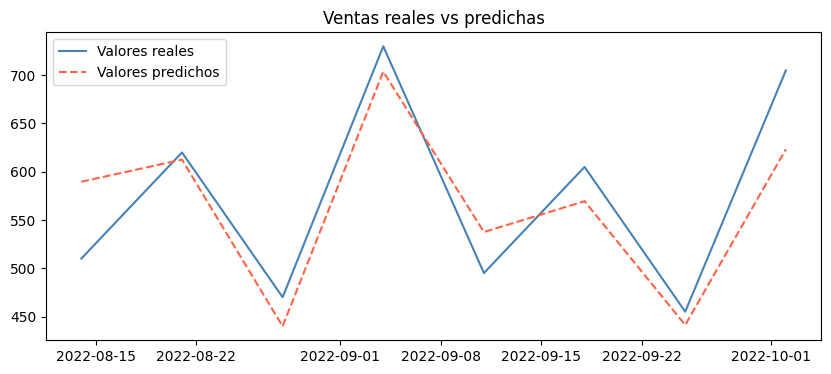

In [10]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Ordenamos por fecha para interpretación temporal correcta
fechas_test = df["fecha"].iloc[split:].values

# Gráfico valores reales vs predichos
plt.figure(figsize=(10, 4))
plt.plot(fechas_test, y_test.values, label="Valores reales", color="steelblue")
plt.plot(fechas_test, y_pred.values, label="Valores predichos", color="tomato", linestyle="--")
plt.title("Ventas reales vs predichas")
plt.legend()
plt.show()

In [11]:
# Resumen completo del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:         ventas_boletos   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     41.73
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.83e-10
Time:                        17:21:10   Log-Likelihood:                -165.95
No. Observations:                  32   AIC:                             339.9
Df Residuals:                      28   BIC:                             345.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     